In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv("wine_quality_merged.csv")

In [ ]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red


In [ ]:
print("Shape of dataset:", df.shape)

print("Column names:")
print(df.columns)

print("Dataset information:")
df.info()

Shape of dataset: (6497, 13)
Column names:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 no

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
print("Missing value in each column:")
print(df.isnull().sum())

Missing value in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1177


In [ ]:
print(df["type"].value_counts())

type
white    4898
red      1599
Name: count, dtype: int64


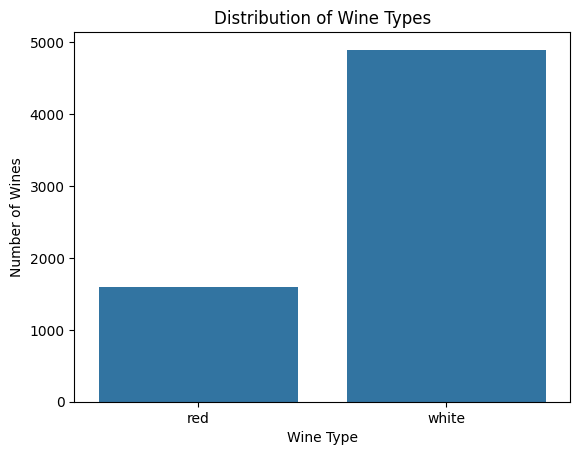

In [ ]:
sns.countplot(data=df, x="type")

plt.title("Distribution of Wine Types")
plt.xlabel("Wine Type")
plt.ylabel("Number of Wines")

plt.show()
#Quantity of white whine is 3x of red wine

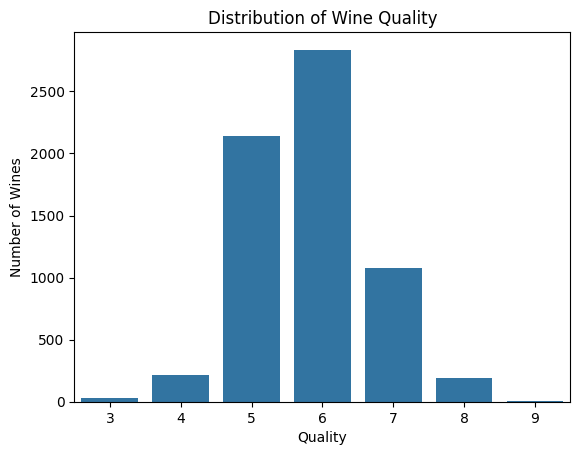

In [ ]:
sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")

plt.show()
#most of the wines has quality between 5 to 6

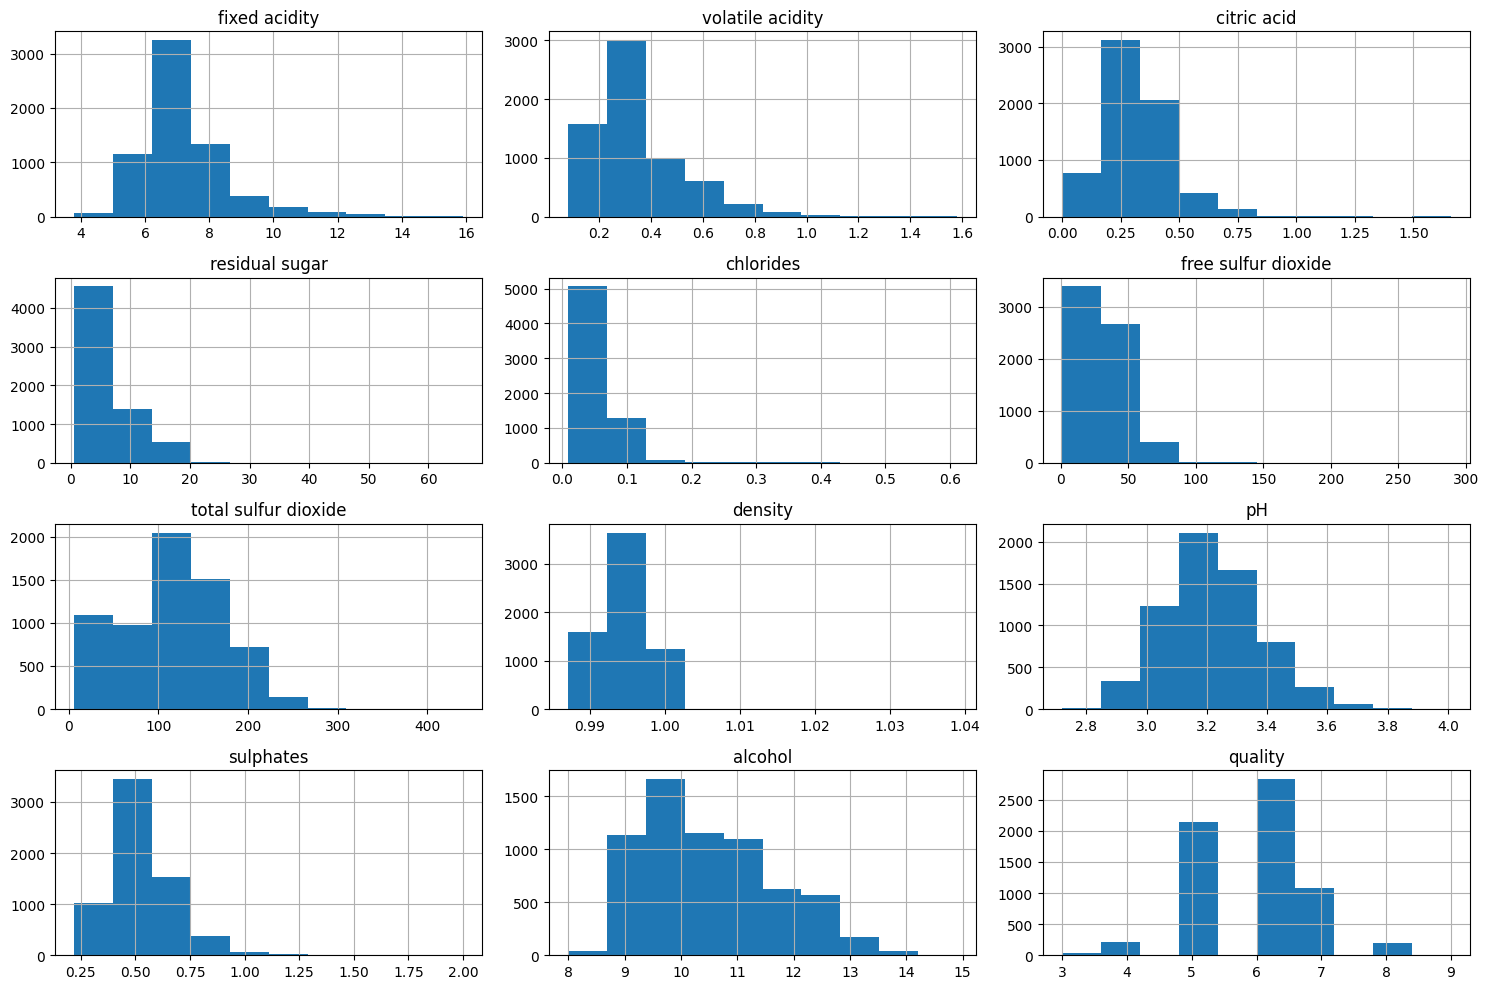

In [ ]:
df.hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

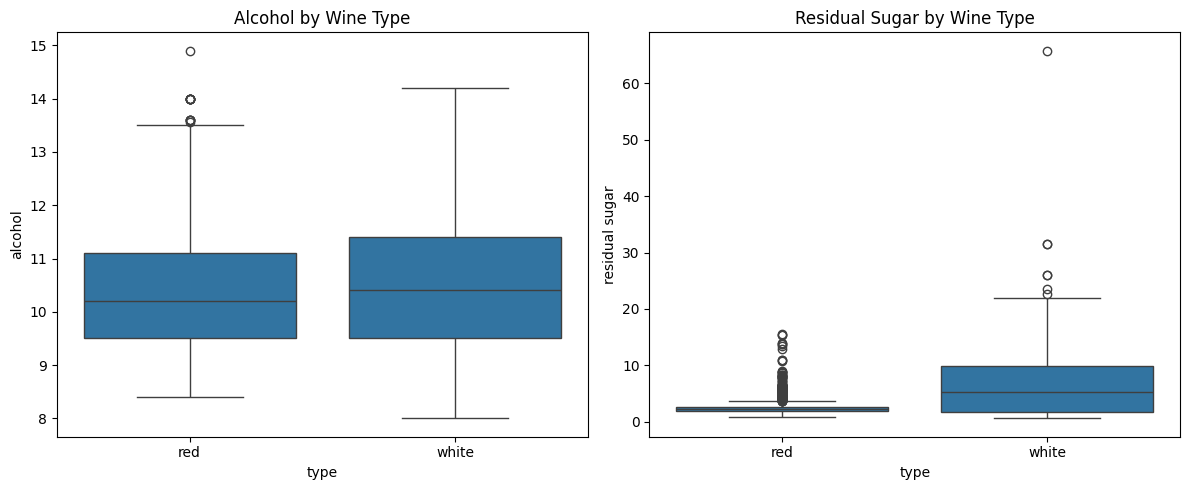

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="type", y="alcohol")
plt.title("Alcohol by Wine Type")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="type", y="residual sugar")
plt.title("Residual Sugar by Wine Type")

plt.tight_layout()
plt.show()

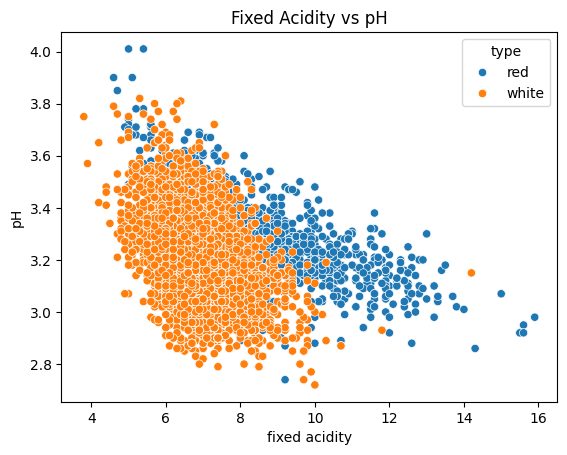

In [ ]:
sns.scatterplot(
    data=df,
    x="fixed acidity",
    y="pH",
    hue="type"
)

plt.title("Fixed Acidity vs pH")
plt.show()
#white wines are slightly more acidic than red wines

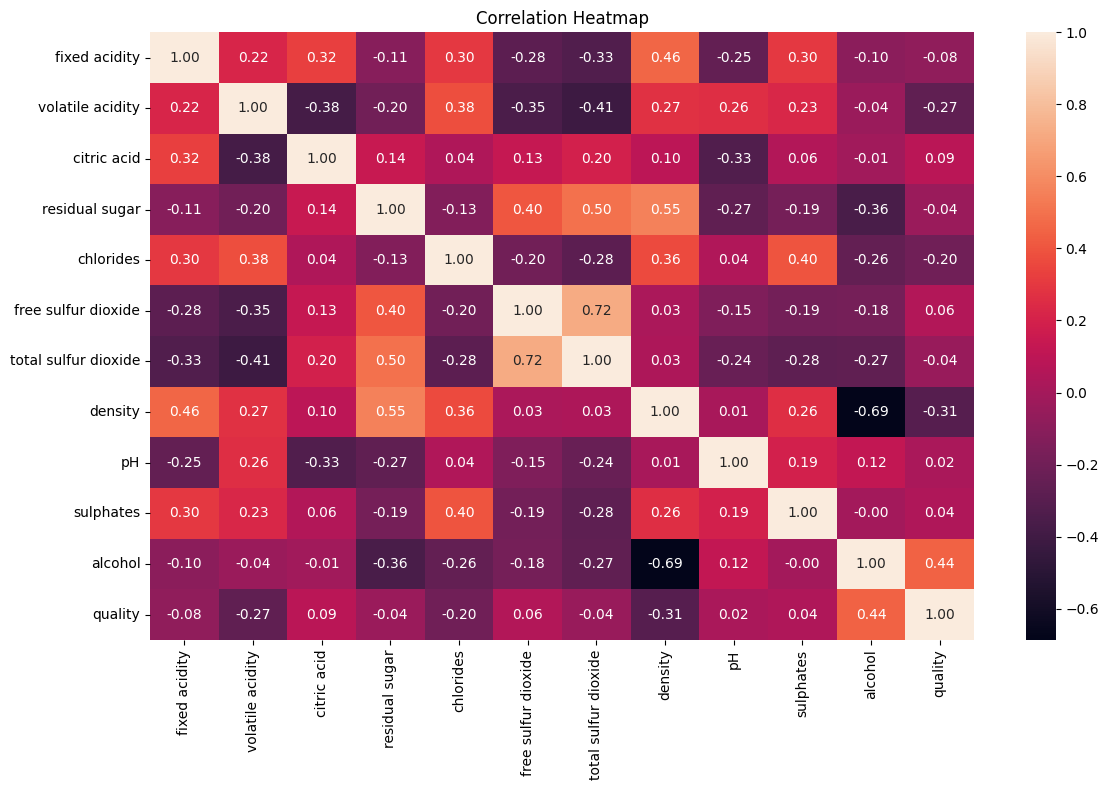

In [ ]:
corr_mat = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()
#free sulfur dioxide is positively correalated to total sulfur dioxide, density is also correlated to residual sugar

In [ ]:
df["type"] = df["type"].map({
    "red": 0,
    "white": 1
})

print(df["type"].value_counts())

type
1    4898
0    1599
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["quality", "type"])
y = df["type"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5197, 11)
Testing data: (1300, 11)


In [ ]:
standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

In [ ]:
minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

In [ ]:
scaling_results = []

# without scaling
model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scaling_results.append(["without scaling", accuracy, f1])


# with StandardScaler
model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform"
)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_test_standard)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scaling_results.append(["StandardScaler", accuracy, f1])


# with MinMaxScaler
model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform"
)

model.fit(X_train_minmax, y_train)
y_pred = model.predict(X_test_minmax)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scaling_results.append(["MinMaxScaler", accuracy, f1])

In [ ]:
scaling_df = pd.DataFrame(
    scaling_results,
    columns=["Scaling", "Accuracy", "F1 Score"]
)

scaling_df

,Scaling,Accuracy,F1 Score
0,without scaling,0.950000,0.967022
1,StandardScaler,0.993846,0.995918
2,MinMaxScaler,0.992308,0.994893


In [ ]:
#After comparing Accuracy and f1 score, we can see best scaling method is StandardScaler
best_scaling="StandardScaler"

In [ ]:
X_train_final = X_train_standard
X_test_final = X_test_standard

In [ ]:
k_values = [3, 5, 7, 9, 11, 15, 20]

accuracy_values = []
f1_values = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="uniform"
    )

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracy_values.append(accuracy)
    f1_values.append(f1)

In [ ]:
k_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": accuracy_values,
    "F1 Score": f1_values
})

k_results

,K,Accuracy,F1 Score
0,3,0.993846,0.995918
1,5,0.993846,0.995918
2,7,0.995385,0.996939
3,9,0.995385,0.996939
4,11,0.994615,0.996430
5,15,0.992308,0.994898
6,20,0.992308,0.994893


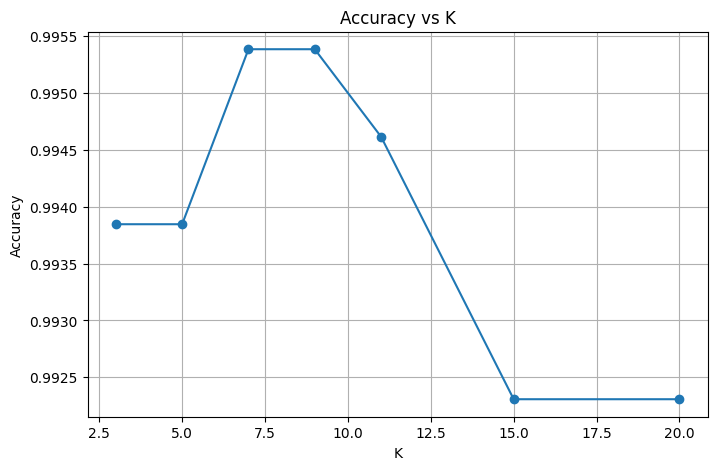

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracy_values,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")

plt.grid()

plt.show()
# best value of k is 7

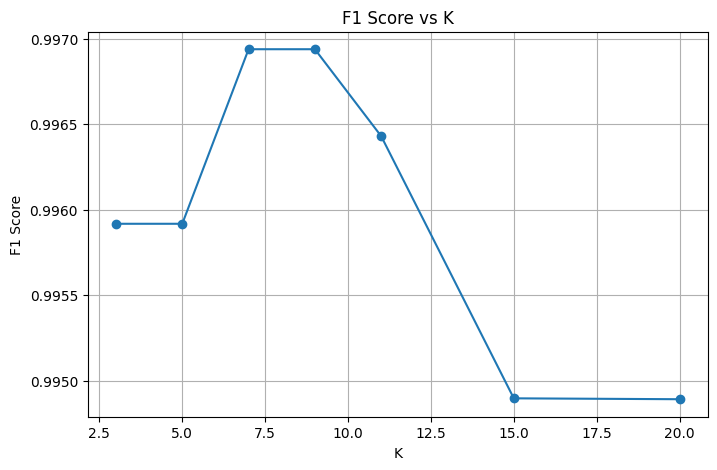

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    f1_values,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("F1 Score")
plt.title("F1 Score vs K")

plt.grid()

plt.show()

In [ ]:
best_k = 7

In [ ]:
metrics = ["euclidean", "manhattan", "minkowski"]

metric_results = []

for metric in metrics:

    if metric == "minkowski":
        model = KNeighborsClassifier(
            n_neighbors=best_k,
            metric=metric,
            p=3,
            weights="uniform"
        )
    else:
        model = KNeighborsClassifier(
            n_neighbors=best_k,
            metric=metric,
            weights="uniform"
        )

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metric_results.append([
        metric,
        accuracy,
        f1
    ])

In [ ]:
metric_df = pd.DataFrame(
    metric_results,
    columns=["Distance Metric", "Accuracy", "F1 Score"]
)

metric_df

,Distance Metric,Accuracy,F1 Score
0,euclidean,0.995385,0.996939
1,manhattan,0.995385,0.996942
2,minkowski,0.994615,0.996427


In [ ]:
best_metric = "manhattan"

print("Best distance metric:", best_metric)

Best distance metric: manhattan


In [ ]:
weights = ["uniform", "distance"]

weight_results = []

for weight in weights:

    if best_metric == "minkowski":
        model = KNeighborsClassifier(
            n_neighbors=best_k,
            metric=best_metric,
            p=3,
            weights=weight
        )
    else:
        model = KNeighborsClassifier(
            n_neighbors=best_k,
            metric=best_metric,
            weights=weight
        )

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    weight_results.append([
        weight,
        accuracy,
        f1
    ])

In [ ]:
weight_df = pd.DataFrame(
    weight_results,
    columns=["Weighting", "Accuracy", "F1 Score"]
)

weight_df

,Weighting,Accuracy,F1 Score
0,uniform,0.995385,0.996942
1,distance,0.994615,0.996427


In [ ]:
best_weight = "uniform"

print("Best weighting method:", best_weight)

Best weighting method: uniform


In [ ]:
final_model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=best_metric,
        weights=best_weight
    )


final_model.fit(X_train_final, y_train)

y_pred = final_model.predict(X_test_final)

In [ ]:
final_accuracy = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

print("Final Model Results")
print("-------------------")
print("Accuracy:", final_accuracy)
print("F1 Score:", final_f1)

Final Model Results
-------------------
Accuracy: 0.9953846153846154
F1 Score: 0.9969418960244648


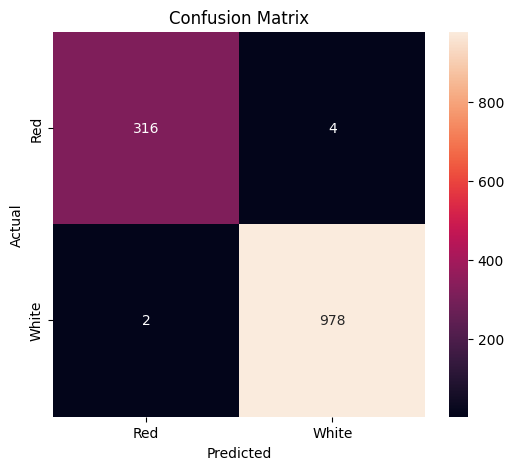

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Red", "White"],
    yticklabels=["Red", "White"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Red", "White"]
    )
)

              precision    recall  f1-score   support

         Red       0.99      0.99      0.99       320
       White       1.00      1.00      1.00       980

    accuracy                           1.00      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       1.00      1.00      1.00      1300



In [ ]:
print("Final Model Configuration")
print("-------------------------")
print("Scaling:", best_scaling)
print("K:", best_k)
print("Distance metric:", best_metric)
print("Weighting:", best_weight)
print("Accuracy:", final_accuracy)
print("F1 Score:", final_f1)

Final Model Configuration
-------------------------
Scaling: StandardScaler
K: 7
Distance metric: manhattan
Weighting: uniform
Accuracy: 0.9953846153846154
F1 Score: 0.9969418960244648
